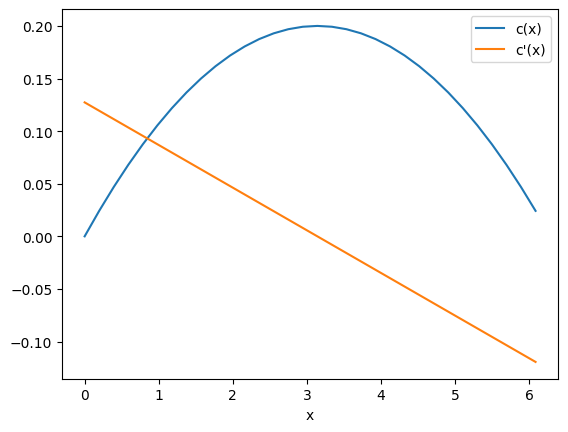

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5

D = 0.1
N = 2**n_qubits
L = 2 * np.pi               
t = 0.4   
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 


plt.plot(x, c, label='c(x)')
plt.plot(x, cx, label='c\'(x)')
plt.xlabel('x')
plt.legend()

Applying shift of 0.0597 to ensure positive semidefiniteness.
Success Probability: 1.4570e-01


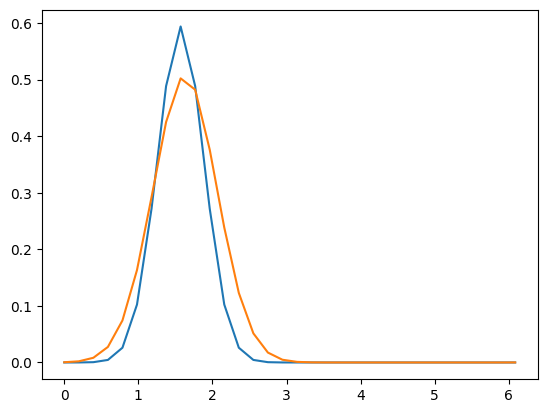

In [13]:
from lchs import lchs

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

lchs_state, success_prob = lchs(n_qubits, t, cx, c, D, L, init_state=state, r_steps=100,   useFixedJ=True, fixed_J=128)

plt.figure()
plt.plot(x, state, label='Initial State')
plt.plot(x, np.real(lchs_state))